# Notebook 05 — Long-range social pressure on a real network (CKM physicians)

**Goal:** Validate the model on a real social network instead of synthetic BA/ER graphs,
using the classic Coleman–Katz–Menzel (1966) "Medical Innovation" physician dataset
(246 physicians, 4 Illinois towns). The data were prepared by Burt (1987) and are
distributed via the `spatialprobit` R package; `real_networks/export_CKM.R` regenerates
the CSVs used below.

**Layer mapping:**
- $G_\mathrm{game}$ = Friendship (A3) — substrate for the PD game / strategy update.
- $G_\mathrm{vig}$ = Advice (A1) — substrate for vigilance influence.

The two relations are genuinely different real ties (not independent realizations of the
same random graph), so this is a third condition distinct from the correlated/uncorrelated
axis of notebooks 02/03: real correlated structure between two different real relations.

**Networks:** the 4 towns are disconnected from each other (zero cross-town edges in both
relations), so each is analyzed separately, exactly as BA/ER at z=4/z=16 are treated as 4
independent topologies. Per town: take the giant component of Friendship, then induce
Advice on that same node set (isolated-in-advice nodes get $I_i=0$, same handling as
uncorrelated synthetic networks).

**λ:** we use λ = 0.65 here (not the illustrative λ = 0.5 of the synthetic-network
sections), directly from the empirical decay coefficient $c_2 \approx 0.65$ measured by
Miranda et al. (2024) — the most precisely measured of their significant circle
coefficients.

Update rule: Fermi (K = 0.1). Parameters: b ∈ [1.0, 2.0], θ ∈ [0.0, 1.0], 100 replications.

**Structure:**
- **Part I — Data loading:** builds the 4 town networks, prints summary stats.
- **Part II — Simulation:** runs the (b, θ) sweep for L = 1..4, saves to `data/05-*.csv`.
- **Part III — Figures:** loads CSVs, makes heatmaps and marginal plots.

In [5]:
# ── Shared: imports and parameters ──────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import model

n_rep    = 100
L_VALUES = [1, 2, 3, 4]
lam      = 0.65
K_fermi  = 0.1
b_vals   = np.round(np.linspace(1.0, 2.0, 11), 2)
th_vals  = np.round(np.linspace(0.0, 1.0, 11), 2)
SIM_SEED = 0
N_JOBS   = -1

CITY_NAMES = {1: 'Peoria', 2: 'Bloomington', 3: 'Quincy', 4: 'Galesburg'}

os.makedirs('data',    exist_ok=True)
os.makedirs('figures', exist_ok=True)
print('b:', b_vals)
print('θ:', th_vals)

b: [1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ]
θ: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


---
## Part I — Data loading

Friendship (A3) and Advice (A1) are directed nomination matrices (each physician names up
to a fixed number of contacts), so they are not symmetric. We symmetrize via the union
rule ($i$–$j$ tied if either nominates the other), which reproduces exactly the giant
component sizes found in the earlier connectivity analysis.

In [6]:
# ── Load CKM data and build per-town networks ───────────────────────────────
if not (os.path.exists('real_networks/A1.csv') and os.path.exists('real_networks/A3.csv')):
    raise FileNotFoundError(
        "real_networks/{A1,A3,CKM_covariates}.csv not found — run "
        "'Rscript real_networks/export_CKM.R' first."
    )

A1  = pd.read_csv('real_networks/A1.csv').values   # advice (directed)
A3  = pd.read_csv('real_networks/A3.csv').values   # friendship (directed)
cov = pd.read_csv('real_networks/CKM_covariates.csv')
city_arr = cov['city'].values


def load_city_networks():
    """Per town: union-symmetrize A3/A1, take A3 giant component, induce A1 on it."""
    networks = {}
    for c, name in CITY_NAMES.items():
        idx = np.where(city_arr == c)[0]
        a1 = A1[np.ix_(idx, idx)]
        a3 = A3[np.ix_(idx, idx)]
        friend = ((a3 + a3.T) > 0).astype(int)
        advice = ((a1 + a1.T) > 0).astype(int)
        np.fill_diagonal(friend, 0)
        np.fill_diagonal(advice, 0)

        G_friend_full = nx.from_numpy_array(friend)
        giant = max(nx.connected_components(G_friend_full), key=len)
        nodes = sorted(giant)

        G_game = nx.from_numpy_array(friend[np.ix_(nodes, nodes)])
        G_vig  = nx.from_numpy_array(advice[np.ix_(nodes, nodes)])
        networks[name] = (G_game, G_vig)
    return networks


city_networks = load_city_networks()

for name, (Gg, Gv) in city_networks.items():
    N = Gg.number_of_nodes()
    deg_g = 2 * Gg.number_of_edges() / N
    deg_v = 2 * Gv.number_of_edges() / N
    iso_v = sum(1 for n in Gv if Gv.degree(n) == 0)
    diam  = nx.diameter(Gg) if nx.is_connected(Gg) else float('nan')
    print(
        f"{name:12s}  N={N:3d}  "
        f"game(friend): <k>={deg_g:.2f} diam={diam}  "
        f"vig(advice): <k>={deg_v:.2f} isolated={iso_v}"
    )

Peoria        N=110  game(friend): <k>=3.51 diam=9  vig(advice): <k>=3.96 isolated=11
Bloomington   N= 46  game(friend): <k>=4.09 diam=6  vig(advice): <k>=3.52 isolated=7
Quincy        N= 38  game(friend): <k>=3.42 diam=8  vig(advice): <k>=3.16 isolated=4
Galesburg     N= 34  game(friend): <k>=4.18 diam=6  vig(advice): <k>=3.82 isolated=2


---
## Part II — Simulation

*Run once. For each town, $G_\mathrm{game}$ = Friendship giant component,
$G_\mathrm{vig}$ = Advice induced on the same nodes.*

In [3]:
# ── Pre-compile JIT kernels ─────────────────────────────────────────────────
model.warm_up()
print('JIT kernels compiled.')

JIT kernels compiled.


In [4]:
# ── Run sweeps ───────────────────────────────────────────────────────────────
for name, (Gg, Gv) in city_networks.items():
    gp, gd = model.game_csr(Gg)
    for L in L_VALUES:
        path = f"data/05-{name}-L{L}.csv"
        if os.path.exists(path):
            print(f"  skip: {path}")
            continue
        print(f"  running {name}  L={L} ...", flush=True)
        sp, sd = model.shells_csr(Gv, L)
        al     = model.geometric_kernel(L, lam)
        df = model.run_sweep(
            gp, gd, sp, sd, al,
            b_vals, th_vals,
            K=K_fermi, n_rep=n_rep,
            n_jobs=N_JOBS, base_seed=SIM_SEED,
            update_rule='fermi',
        )
        df.to_csv(path, index=False)
        print(f"  saved: {path}")

print('Part II done.')

  running Peoria  L=1 ...


  saved: data/05-Peoria-L1.csv
  running Peoria  L=2 ...


  saved: data/05-Peoria-L2.csv
  running Peoria  L=3 ...


  saved: data/05-Peoria-L3.csv
  running Peoria  L=4 ...


  saved: data/05-Peoria-L4.csv
  running Bloomington  L=1 ...


...

  saved: data/05-Quincy-L4.csv
  running Galesburg  L=1 ...


  saved: data/05-Galesburg-L1.csv
  running Galesburg  L=2 ...


  saved: data/05-Galesburg-L2.csv
  running Galesburg  L=3 ...


  saved: data/05-Galesburg-L3.csv
  running Galesburg  L=4 ...


  saved: data/05-Galesburg-L4.csv
Part II done.


---
## Part III — Figures

*Loads CSVs from `data/`.*

In [7]:
# ── Load results ──────────────────────────────────────────────────────────
CITIES = list(CITY_NAMES.values())
data05 = {}
for name in CITIES:
    for L in L_VALUES:
        data05[(name, L)] = pd.read_csv(f"data/05-{name}-L{L}.csv")
print('loaded', len(data05), 'result files')

loaded 16 result files


In [8]:
# ── Figure settings (same palette as notebooks 01-04) ───────────────────────
import matplotlib as mpl

plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 120,
})

CMAP = 'GnBu'
VMIN, VMAX = 0.0, 1.0
THETA_SHOW = [0.3, 0.5, 0.7]

_d2      = mpl.colormaps['Dark2']
DARK2    = {1: _d2(0), 2: _d2(1), 3: _d2(2), 4: _d2(3)}
L_STYLES = {1: '-',   2: '--',   3: '-.',   4: ':'}
LW       = 2.0

db, dt = b_vals[1] - b_vals[0], th_vals[1] - th_vals[0]
EXTENT = [b_vals[0]-db/2, b_vals[-1]+db/2, th_vals[0]-dt/2, th_vals[-1]+dt/2]

def rho_matrix(df):
    return (
        df.pivot(index='theta', columns='b', values='rho_mean')
          .sort_index(ascending=True)
          .values
    )

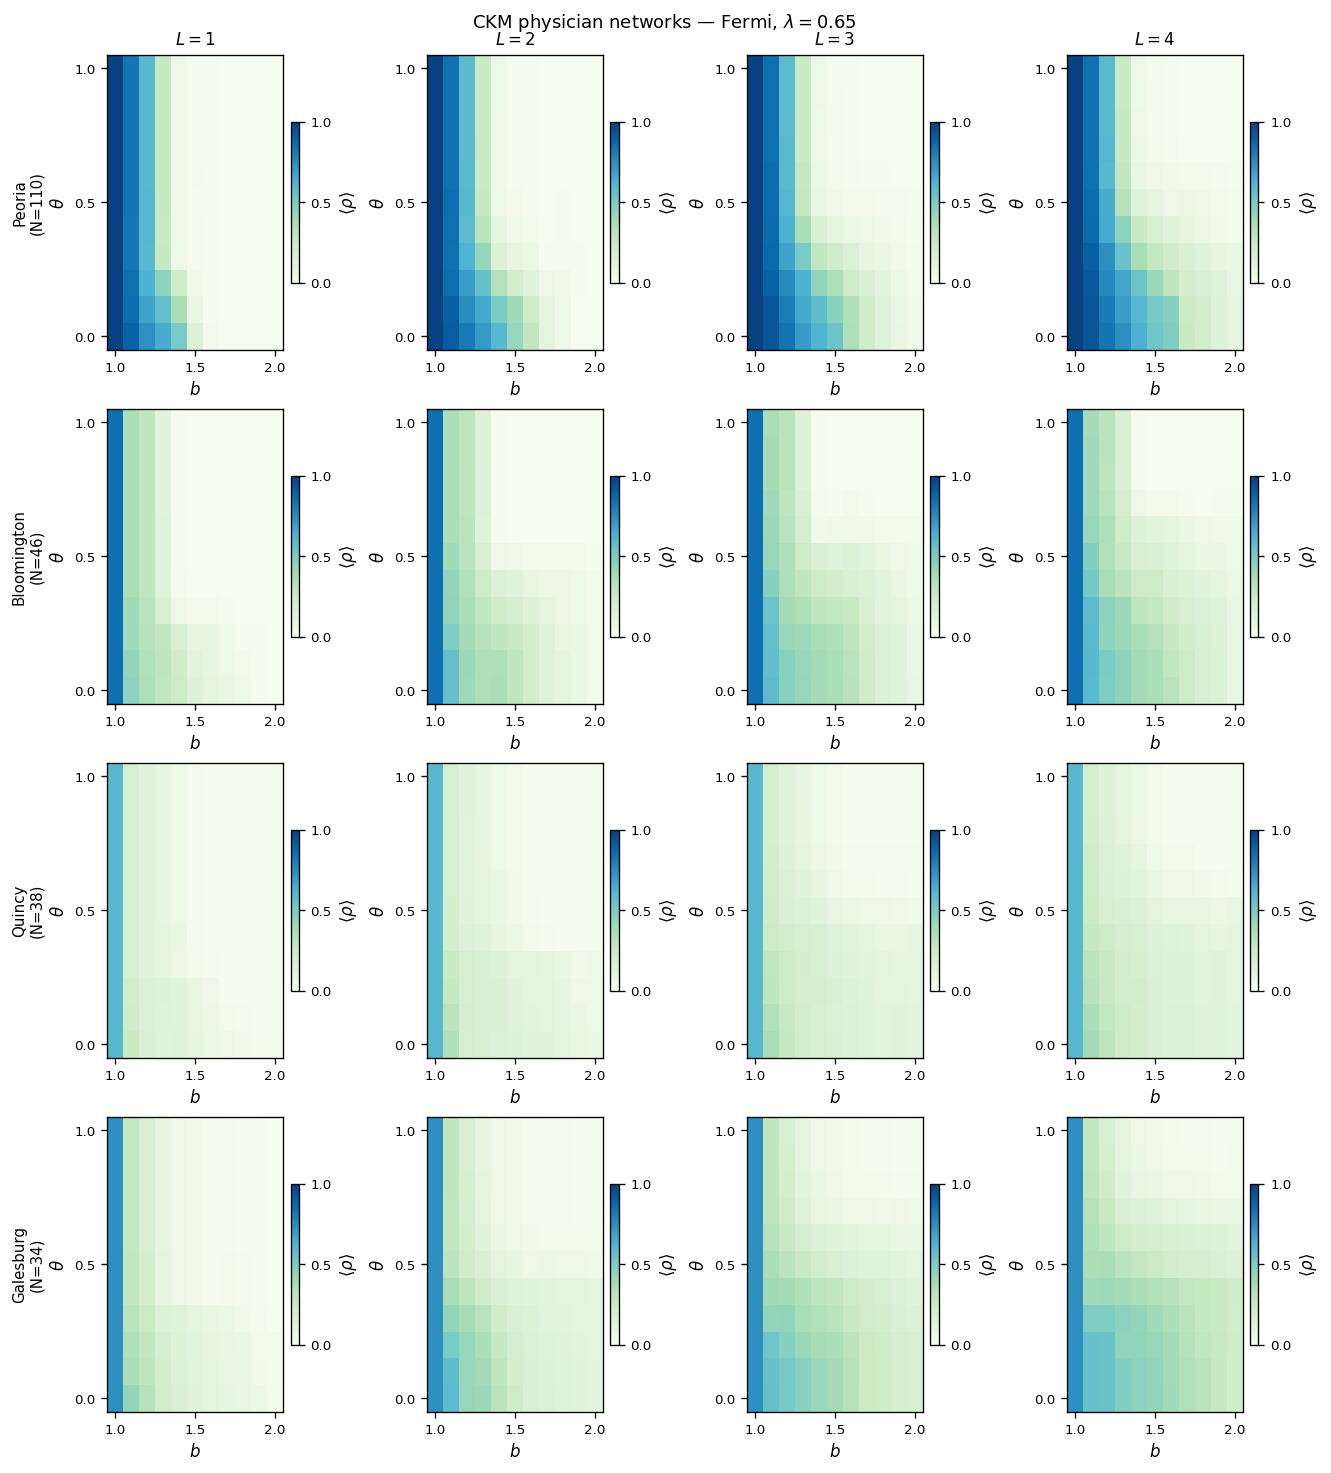

Saved figures/05-heatmaps.pdf


In [9]:
# ── Figure 1: heatmaps — rows = towns, cols = L ──────────────────────────────
fig1, axes = plt.subplots(
    len(CITIES), len(L_VALUES),
    figsize=(11, 12),
    constrained_layout=True,
)

for row, name in enumerate(CITIES):
    N = city_networks[name][0].number_of_nodes()
    for col, L in enumerate(L_VALUES):
        ax  = axes[row, col]
        mat = rho_matrix(data05[(name, L)])
        im  = ax.imshow(mat, origin='lower', aspect='auto',
                        vmin=VMIN, vmax=VMAX, cmap=CMAP, extent=EXTENT)
        ax.set_xlabel('$b$'); ax.set_ylabel(r'$\theta$')
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.5))
        if row == 0: ax.set_title(f'$L={L}$', fontweight='bold')
        if col == 0:
            ax.text(-0.45, 0.5, f'{name}\n(N={N})', transform=ax.transAxes,
                    rotation=90, va='center', ha='center', fontsize=9)
        cb = fig1.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.set_label(r'$\langle\rho\rangle$'); cb.set_ticks([0, 0.5, 1.0])

fig1.suptitle(r'CKM physician networks — Fermi, $\lambda=0.65$', y=1.01)
fig1.savefig('figures/05-heatmaps.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/05-heatmaps.pdf')

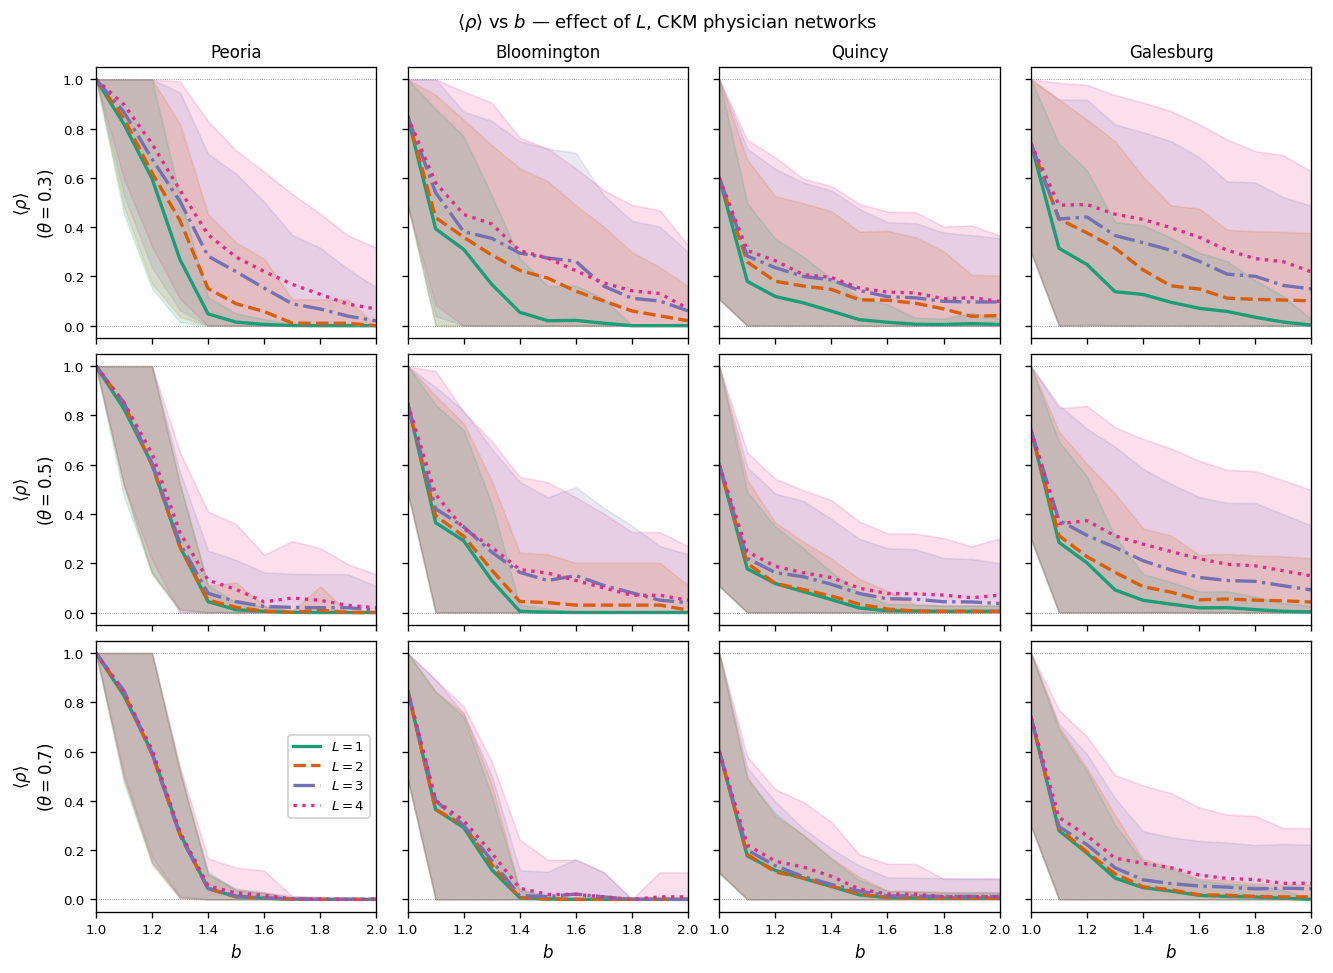

Saved figures/05-marginals.pdf


In [10]:
# ── Figure 2: marginals rho vs b at selected theta values ───────────────────
fig2, axes2 = plt.subplots(
    len(THETA_SHOW), len(CITIES),
    figsize=(11, 8),
    constrained_layout=True,
    sharey=True, sharex=True,
)

for col, name in enumerate(CITIES):
    for row, th in enumerate(THETA_SHOW):
        ax = axes2[row, col]
        # fills in reverse L order so L=1 (green) sits on top
        for L in reversed(L_VALUES):
            df  = data05[(name, L)]
            sub = df[np.isclose(df['theta'], th)].sort_values('b')
            ax.fill_between(
                sub['b'],
                (sub['rho_mean'] - sub['rho_std']).clip(0),
                (sub['rho_mean'] + sub['rho_std']).clip(0, 1),
                alpha=0.15, color=DARK2[L],
            )
        # lines on top of all fills
        for L in L_VALUES:
            df  = data05[(name, L)]
            sub = df[np.isclose(df['theta'], th)].sort_values('b')
            ax.plot(
                sub['b'], sub['rho_mean'],
                color=DARK2[L], linestyle=L_STYLES[L],
                label=f'$L={L}$', lw=LW,
            )
        if row == 0:
            ax.set_title(name)
        if col == 0:
            ax.set_ylabel(f'$\\langle\\rho\\rangle$\n($\\theta={th}$)')
        if row == len(THETA_SHOW) - 1:
            ax.set_xlabel('$b$')
        if row == len(THETA_SHOW) - 1 and col == 0:
            ax.legend(fontsize=8, framealpha=0.9)
        ax.set_xlim(1.0, 2.0)
        ax.set_ylim(-0.05, 1.05)
        ax.axhline(0, color='grey', lw=0.5, ls=':')
        ax.axhline(1, color='grey', lw=0.5, ls=':')

fig2.suptitle(r'$\langle\rho\rangle$ vs $b$ — effect of $L$, CKM physician networks')
fig2.savefig('figures/05-marginals.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/05-marginals.pdf')